<a href="https://colab.research.google.com/github/Priya-Kumari-Chourasia/ml_algo/blob/main/bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
uciml_iris_path = kagglehub.dataset_download('uciml/iris')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df = df.drop(columns= ['Id'])

In [ ]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['Species'] = encoder.fit_transform(df['Species'])

In [ ]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalWidthCm','Species']]

In [ ]:
df.head()

,SepalWidthCm,PetalWidthCm,Species
50,3.2,1.4,1
51,3.2,1.5,1
52,3.1,1.5,1
53,2.3,1.3,1
54,2.8,1.5,1


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

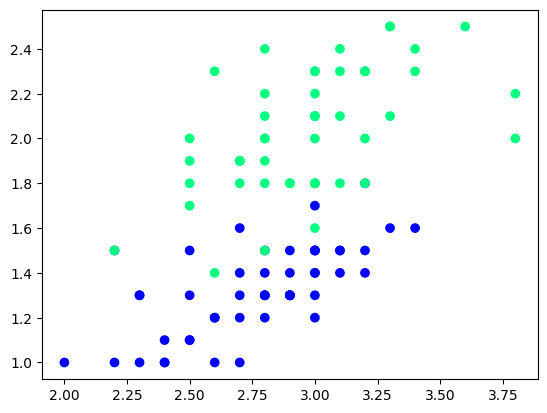

In [ ]:
plt.scatter(df['SepalWidthCm'],df['PetalWidthCm'],c=df['Species'],cmap='winter')

In [ ]:
df =df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [ ]:
df_train

,SepalWidthCm,PetalWidthCm,Species
52,3.1,1.5,1
112,3.0,2.1,2
54,2.8,1.5,1
97,2.9,1.3,1
142,2.7,1.9,2
111,2.7,1.9,2
65,3.1,1.4,1
114,2.8,2.4,2
98,2.5,1.1,1
132,2.8,2.2,2


In [ ]:
x_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

## Case 1 Bagging

In [ ]:
df_bag = df_train.sample(8,replace=True)
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalWidthCm,Species
114,2.8,2.4,2
142,2.7,1.9,2
65,3.1,1.4,1
97,2.9,1.3,1
112,3.0,2.1,2
52,3.1,1.5,1
142,2.7,1.9,2
114,2.8,2.4,2


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [ ]:
dt_bag1 = DecisionTreeClassifier()

In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(x_test)
    print(accuracy_score(y_test,y_pred))


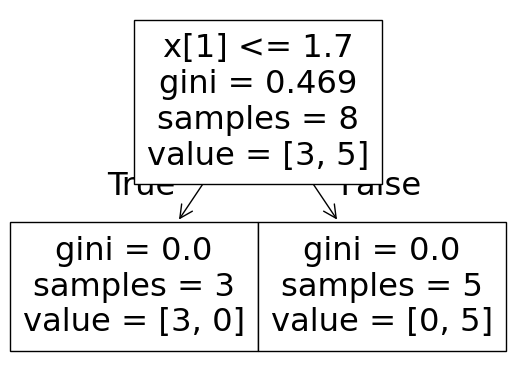

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


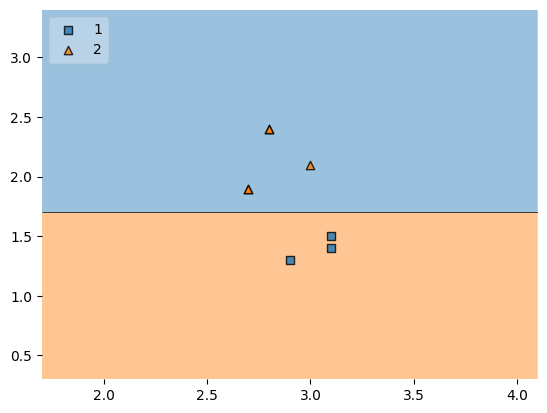

In [ ]:
evaluate(dt_bag1,x,y)

In [ ]:
df_bag = df_train.sample(8,replace=True)
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalWidthCm,Species
52,3.1,1.5,1
65,3.1,1.4,1
54,2.8,1.5,1
65,3.1,1.4,1
142,2.7,1.9,2
111,2.7,1.9,2
114,2.8,2.4,2
98,2.5,1.1,1


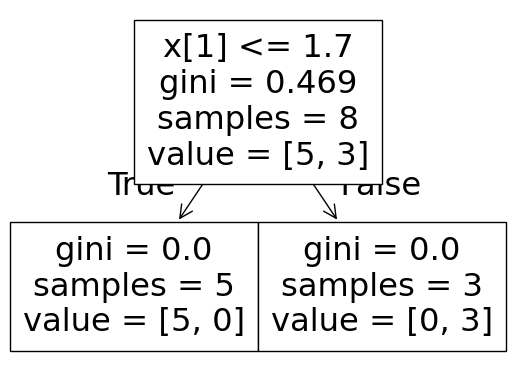

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


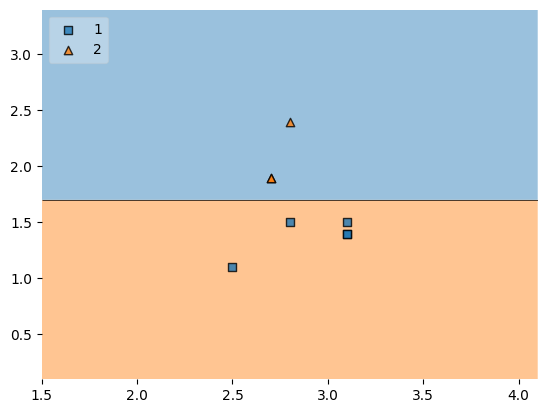

In [ ]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

In [ ]:
df_bag = df_train.sample(8,replace=True)
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalWidthCm,Species
52,3.1,1.5,1
97,2.9,1.3,1
98,2.5,1.1,1
54,2.8,1.5,1
97,2.9,1.3,1
65,3.1,1.4,1
52,3.1,1.5,1
114,2.8,2.4,2


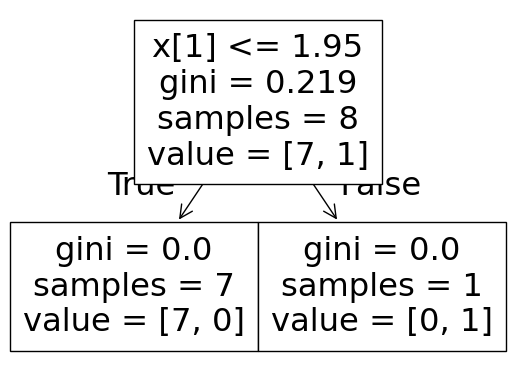

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


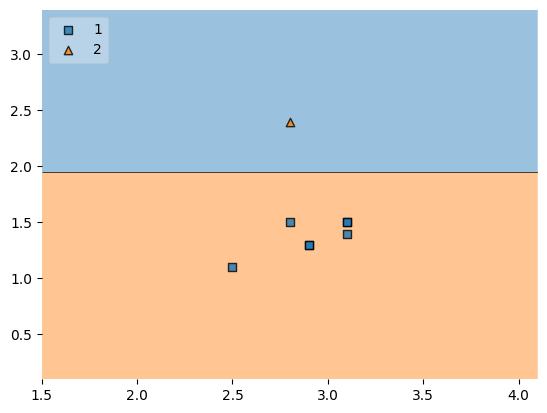

In [ ]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

### Predict

In [ ]:
df_test

,SepalWidthCm,PetalWidthCm,Species
101,2.7,1.9,2
123,2.7,1.8,2
126,2.8,1.8,2
113,2.5,2.0,2
135,3.0,2.3,2


In [ ]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,2.3]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,2.3]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,2.3]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Pasting

In [ ]:
#Row sampling without replacement
df_train

,SepalWidthCm,PetalWidthCm,Species
52,3.1,1.5,1
112,3.0,2.1,2
54,2.8,1.5,1
97,2.9,1.3,1
142,2.7,1.9,2
111,2.7,1.9,2
65,3.1,1.4,1
114,2.8,2.4,2
98,2.5,1.1,1
132,2.8,2.2,2


In [ ]:
df_train.sample(8)

,SepalWidthCm,PetalWidthCm,Species
142,2.7,1.9,2
65,3.1,1.4,1
111,2.7,1.9,2
98,2.5,1.1,1
112,3.0,2.1,2
114,2.8,2.4,2
132,2.8,2.2,2
54,2.8,1.5,1


## Random Subspaces

In [ ]:
# do column sampling
df1 = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')

In [ ]:
df1 = df1.sample(10)

In [ ]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
142,143,5.8,2.7,5.1,1.9,Iris-virginica
92,93,5.8,2.6,4.0,1.2,Iris-versicolor
20,21,5.4,3.4,1.7,0.2,Iris-setosa
107,108,7.3,2.9,6.3,1.8,Iris-virginica
19,20,5.1,3.8,1.5,0.3,Iris-setosa
82,83,5.8,2.7,3.9,1.2,Iris-versicolor
99,100,5.7,2.8,4.1,1.3,Iris-versicolor
147,148,6.5,3.0,5.2,2.0,Iris-virginica
119,120,6.0,2.2,5.0,1.5,Iris-virginica
57,58,4.9,2.4,3.3,1.0,Iris-versicolor


In [ ]:
df1.sample(2,replace =True,axis=1)

,SepalLengthCm,PetalWidthCm
142,5.8,1.9
92,5.8,1.2
20,5.4,0.2
107,7.3,1.8
19,5.1,0.3
82,5.8,1.2
99,5.7,1.3
147,6.5,2.0
119,6.0,1.5
57,4.9,1.0


## Random Patches

In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalLengthCm,Species
19,1.5,Iris-setosa
57,3.3,Iris-versicolor
19,1.5,Iris-setosa
99,4.1,Iris-versicolor
107,6.3,Iris-virginica
92,4.0,Iris-versicolor
119,5.0,Iris-virginica
147,5.2,Iris-virginica
